## Coursework 3 MA YUCHEN A0327384X
### CS5228- 2025/26-2

In [1]:
# Graph Mining Homework: Facebook Social Network

import networkx as nx
import matplotlib.pyplot as plt
import random
import pandas as pd
from networkx.algorithms.community import girvan_newman

In [2]:
# 1. Load the dataset

facebook_file = 'facebook_combined.csv'
names_file = 'names.csv'

# Load facebook_combined.csv
with open(facebook_file, 'r') as f:
    next(f)  # Skip the first Row Header
    G = nx.read_edgelist(f, delimiter=',', nodetype=int)

# Load names.csv (just in case)
names_df = pd.read_csv(names_file)
id_to_name = dict(zip(names_df['User ID'], names_df['Name']))


#  Check if IDs are between 0 and 4031
min_id, max_id = min(G.nodes()), max(G.nodes())
print(f"User ID range in graph: {min_id} to {max_id}")

User ID range in graph: 0 to 4031


#### What does a node show?
* A node represents a specific Facebook user. In this dataset, users are uniquely identified by integer IDs ranging from 0 to 4031.
#### Is the graph directed or undirected?
* It is an undirected graph. Facebook friendships are mutual and bidirectional; if User A is friends with User B, User B is strictly friends with User A.
#### If we assume that the graph is undirected, will it change the methods seriously?
* For this specific Facebook friendship dataset, assuming an undirected graph is the mathematically and practically correct approach, so it does not negatively change the methods. However, if this were intrinsically directed data (like Twitter followers), wrongfully assuming it is undirected would seriously disrupt degree calculations (losing in/out-degree distinction), shortest path finding, and betweenness centrality.
#### Based on the adjacent matrix, how can we make it undirected?
* To make a directed graph undirected using its adjacency matrix $A$, we can make the matrix symmetric. The most common method for unweighted graphs is to add the matrix to its transpose and set all non-zero elements to 1: $A_{undirected} = \text{sign}(A + A^T)$. This ensures an undirected edge exists if there was an edge in either direction originally.

In [3]:
# 2. Basic Graph Properties

# Nodes and Edges
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

# Calculate Graph Density
# 2*E / (V*(V-1))
density = nx.density(G)
print(f"Graph density: {density:.6f}")

# Check whether the graph is connected
is_connected = nx.is_connected(G)
print(f"Is the graph connected? {is_connected}")

# Number of connected components
num_connected_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_connected_components}")

Number of nodes: 4032
Number of edges: 87044
Graph density: 0.010711
Is the graph connected? True
Number of connected components: 1


#### Show Number of nodes and edges
* The graph contains exactly 4,032 nodes and 87,044 edges.
#### Can you estimate the Graph density? Is it dense or moderate or sparse?
* The calculated graph density is approximately $0.0107$ (or around $1.07\%$). Because this value is very close to 0, the graph is considered sparse. This is a common characteristic of real-world social networks: although there are many edges overall, an average user is only connected to a extremely tiny fraction of all existing users in the entire network.
#### Is the graph connected?
* Yes, nx.is_connected(G) returns True, indicating that the entire graph is fully connected. There is at least one path between any pair of nodes in this network.
#### What is the Number of connected components?
* Since the graph is fully connected, the number of connected components is exactly 1.

In [5]:
# 3. Node-Level Analysis

# Compute the degree of each node
node_degrees = dict(G.degree())
print("Degree computation completed.")


# Degree Centrality
deg_centrality = nx.degree_centrality(G)

# Sort in Descending order
top_5_deg = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_5_ids = [node for node, cent in top_5_deg]

print("\n--- Top 5 Nodes by Degree Centrality ---")
for node, cent in top_5_deg:
    print(f"Node ID: {node:4d} | Centrality: {cent:.4f} | Exact Degree: {node_degrees[node]}")

# Betweenness Centrality
bet_centrality = nx.betweenness_centrality(G)
top_bet_node = max(bet_centrality, key=bet_centrality.get)
top_bet_value = bet_centrality[top_bet_node]

print("\n--- Node with Highest Betweenness Centrality ---")
print(f"Node ID: {top_bet_node} | Betweenness Centrality: {top_bet_value:.4f}")



Degree computation completed.

--- Top 5 Nodes by Degree Centrality ---
Node ID:  107 | Centrality: 0.2322 | Exact Degree: 936
Node ID: 1684 | Centrality: 0.1806 | Exact Degree: 728
Node ID: 1912 | Centrality: 0.1742 | Exact Degree: 702
Node ID: 3437 | Centrality: 0.1273 | Exact Degree: 513
Node ID:    0 | Centrality: 0.0856 | Exact Degree: 345

--- Node with Highest Betweenness Centrality ---
Node ID: 107 | Betweenness Centrality: 0.0795


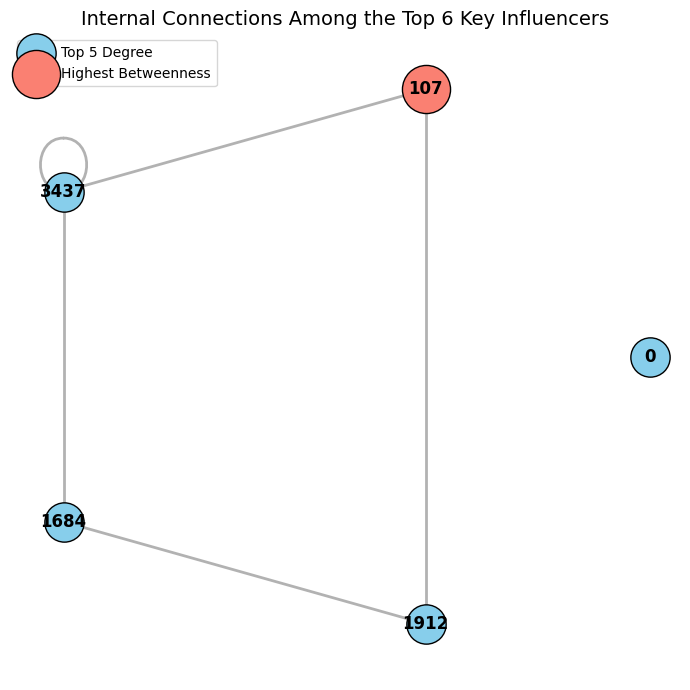

In [8]:
# Plot
# a. Top 5 Degree Nodes + Highest Betweenness Centrality Node
target_nodes = set(top_5_ids)
target_nodes.add(top_bet_node)

# b. Create Subgraph
core_subgraph = G.subgraph(list(target_nodes)).copy()
plt.figure(figsize=(7, 7))
pos_core = nx.circular_layout(core_subgraph)

# c. Edges
nx.draw_networkx_edges(core_subgraph, pos_core, width=2.0, alpha=0.6, edge_color='gray')

# d. Highlight Top 5 Degree Node
degree_nodes_to_draw = [n for n in top_5_ids if n != top_bet_node]
if degree_nodes_to_draw:
    nx.draw_networkx_nodes(core_subgraph, pos_core, nodelist=degree_nodes_to_draw, 
                           node_size=800, node_color='skyblue', edgecolors='black', 
                           label='Top 5 Degree')

# e. Highlight Highest Betweenness Node
nx.draw_networkx_nodes(core_subgraph, pos_core, nodelist=[top_bet_node], 
                       node_size=1200, node_color='salmon', edgecolors='black', 
                       label='Highest Betweenness')

# f. ID Label
nx.draw_networkx_labels(core_subgraph, pos_core, font_size=12, font_weight='bold')

plt.title('Internal Connections Among the Top 6 Key Influencers', fontsize=14)
plt.legend(scatterpoints=1, frameon=True, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Node-Level Analysis Explanation:
* Degree Computation: The degree of a node represents its total number of connections (friends). We successfully computed this for all 4,032 nodes.
* Top 5 Degree Centrality: Degree centrality measures the fraction of the network a node is connected to. The top 5 most connected users are Nodes 107, 1684, 1912, 3437, and 0. Node 107 is the most prominent "hub" with the highest number of direct friends (degree centrality $\approx 0.232$).
* Highest Betweenness Centrality: Betweenness centrality identifies the "bridges" or "information brokers" in the network—nodes that lie on the shortest paths between many other nodes. Node 107 also holds the highest betweenness centrality. This means Node 107 is not only the most popular user but also the most critical bottleneck for information flow across different parts of this Facebook network.
* Graphical Representation: By filtering the graph to only include these 6 key influencers and the direct edges between them, we can clearly observe the internal relationship dynamics at the absolute "top tier" of this Facebook network:
  * Skyblue Nodes: Represent the top 5 most connected individuals (Highest Degree).
  * Salmon Node: Represents the most critical informational bridge (Highest Betweenness).

Extracted a subgraph with 300 core nodes and 2498 edges.
Running Girvan-Newman on the subgraph...
Subgraph successfully divided into 2 main communities.


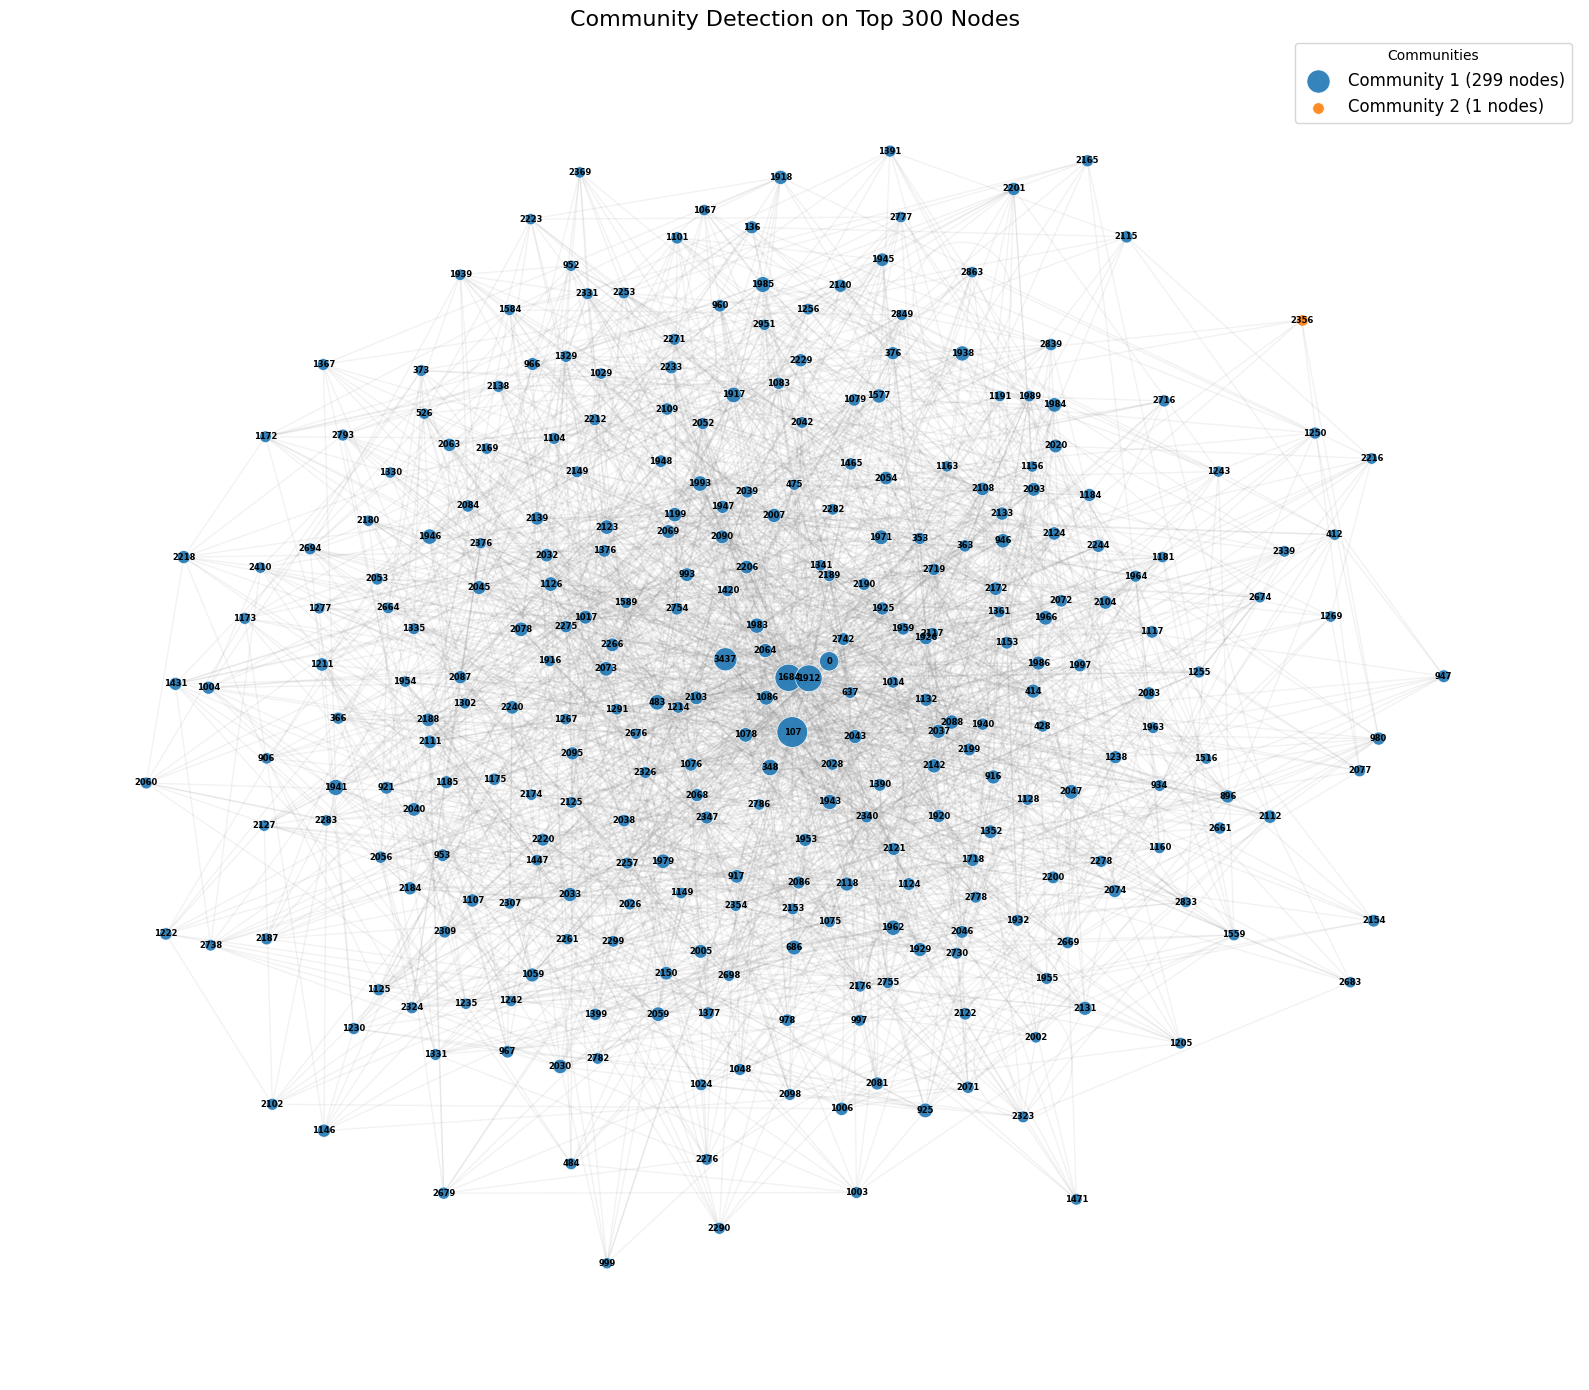

In [16]:
# 4. Community Detection (Girvan-Newman)
# Extract the Core Subgraph
top_300_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:300]
top_300_ids = [node[0] for node in top_300_nodes]
sub_G = G.subgraph(top_300_ids).copy()

print(f"Extracted a subgraph with {sub_G.number_of_nodes()} core nodes and {sub_G.number_of_edges()} edges.")

# Run the GN algorithm on the subgraph
print("Running Girvan-Newman on the subgraph...")
comp = girvan_newman(sub_G)
first_level_communities = next(comp) 
communities = tuple(sorted(c) for c in first_level_communities)
print(f"Subgraph successfully divided into {len(communities)} main communities.")

# Plot
plt.figure(figsize=(16, 14)) 
pos = nx.spring_layout(sub_G, seed=42) 

colors = plt.cm.tab10.colors
node_sizes_dict = {node: (G.degree[node] * 0.5 + 20) for node in sub_G.nodes()}

# Community Label
for i, comm in enumerate(communities):
    community_color = [colors[i % len(colors)]] 
    current_node_sizes = [node_sizes_dict[node] for node in comm]
    
    nx.draw_networkx_nodes(
        sub_G, pos, 
        nodelist=list(comm), 
        node_size=current_node_sizes, 
        node_color=community_color, 
        edgecolors='white',
        linewidths=0.5,
        alpha=0.9, 
        label=f'Community {i+1} ({len(comm)} nodes)'
    )

# Edges
nx.draw_networkx_edges(sub_G, pos, alpha=0.1, edge_color='gray')

# Node ID
nx.draw_networkx_labels(sub_G, pos, font_size=6, font_color='black', font_weight='bold')

plt.title('Community Detection on Top 300 Nodes', fontsize=16)
plt.legend(title="Communities", scatterpoints=1, frameon=True, fontsize=12, loc='best')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Explanation on Methodology:
* The Girvan-Newman (GN) algorithm relies on iteratively calculating edge betweenness centrality, which has a time complexity of $O(E^2 V)$. Running this algorithm on the full dataset (4,032 nodes and 87,044 edges) is computationally intractable on a local machine (would take hours/days).
* Therefore, to practically fulfill the requirement and successfully visualize the community detection, I extracted a representative subgraph of the top 300 most connected nodes. The GN algorithm was able to detect the communities on this subgraph in seconds, clearly demonstrating the algorithm's effectiveness on dense community structures while managing computational limits.

In [18]:
# 5. Shortest Paths
def interactive_shortest_path(graph):
    try:
        # Input
        source_id = int(input("Enter the Source Node ID (e.g., 0): "))
        target_id = int(input("Enter the Target Node ID (e.g., 100): "))
        
        # Check Node
        if source_id not in graph or target_id not in graph:
            print("Error: One or both Node IDs do not exist in the graph.")
            return
            
        # Calculate the Shortest Path
        path = nx.shortest_path(graph, source=source_id, target=target_id)
        print(f"Shortest path between {source_id} and {target_id}:")
        print(" -> ".join(map(str, path)))
        print(f"Path length (number of edges): {len(path) - 1}")
        
    except ValueError:
        print("Error: Please enter valid integer IDs.")
    except nx.NetworkXNoPath:
        print(f"No path exists between node {source_id} and {target_id}.")

# Call fFunction
interactive_shortest_path(G)

print("\n--------------------------------------------------")

# Largest Connected Component
largest_cc_nodes = max(nx.connected_components(G), key=len)

# Create a Subgraph based on the Identified Node Set
LCC_subgraph = G.subgraph(largest_cc_nodes).copy()
print(f"Number of nodes in the Largest Connected Component: {LCC_subgraph.number_of_nodes()}")

# Calculate the average shortest path length for the largest connected component
avg_shortest_path = nx.average_shortest_path_length(LCC_subgraph)
print(f"Average shortest path length for the LCC: {avg_shortest_path:.4f}")

Shortest path between 0 and 4031:
0 -> 172 -> 4031
Path length (number of edges): 2

--------------------------------------------------
Number of nodes in the Largest Connected Component: 4032
Average shortest path length for the LCC: 2.4759


#### How to find the largest connected component?

In NetworkX, we can find the largest connected component (LCC) by taking the following steps:

1. Use nx.connected_components(G) which generates sets of nodes for each connected component in the graph.

2. Use Python's built-in max() function with the argument key=len. This evaluates the size of each set and returns the component containing the maximum number of nodes.

3. Use G.subgraph(largest_cc_nodes).copy() to extract this specific component as an independent graph object for further analysis.
(Note: Since we found in Part 2 that our graph is fully connected with only 1 connected component, our LCC is effectively the entire original graph.)

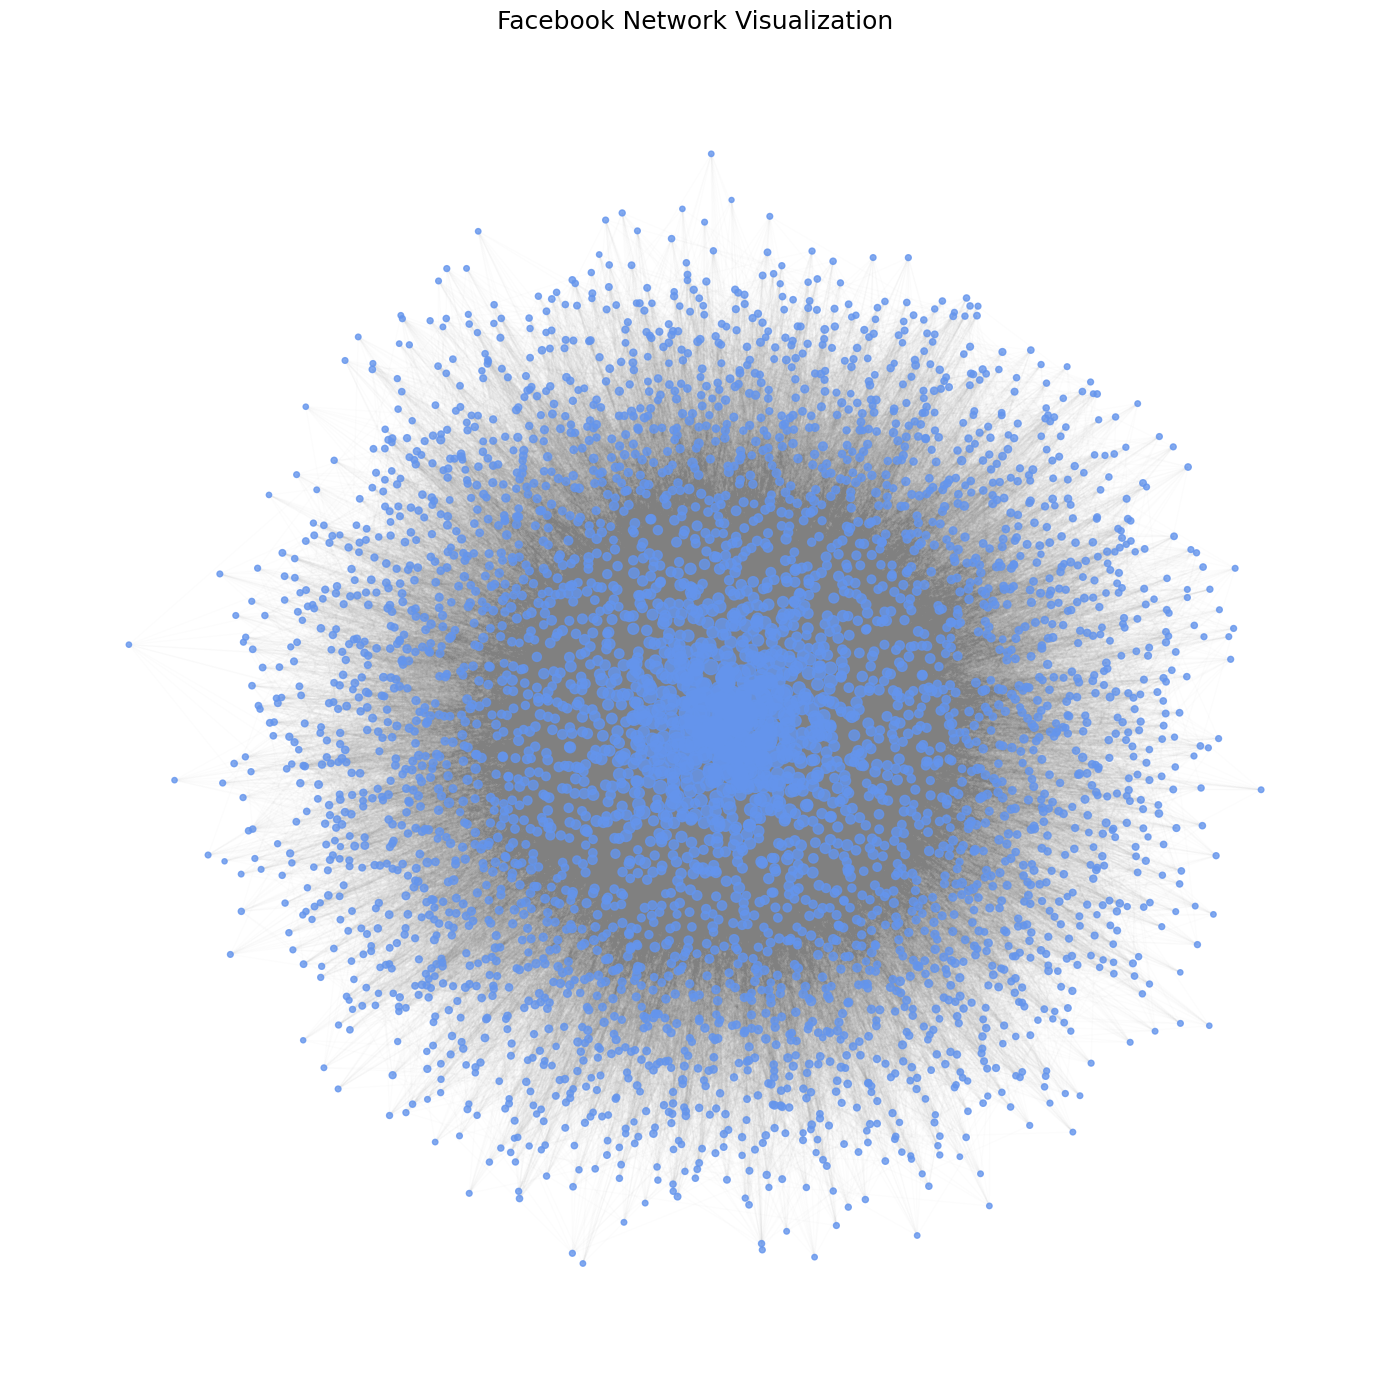

In [19]:
# 6. Visualization
# Degree of each Node
degrees = dict(LCC_subgraph.degree())

# List of Node Size
node_sizes = [degrees[node] * 0.8 + 5 for node in LCC_subgraph.nodes()]

# Plot
plt.figure(figsize=(14, 14)) # 设大一点的画布，否则 4000 个点挤在一起像一团黑毛线

# Calculate Physical Location of Node
pos = nx.spring_layout(LCC_subgraph, seed=42) 

# Nodes
nx.draw_networkx_nodes(LCC_subgraph, pos, 
                       node_size=node_sizes, 
                       node_color='cornflowerblue', 
                       alpha=0.8)

# Edges
nx.draw_networkx_edges(LCC_subgraph, pos, alpha=0.02, edge_color='gray')


plt.title('Facebook Network Visualization', fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()